In [2]:
import polars as pl
from hydra import initialize, compose
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
from cgr.rule_writing import filter_by_pub_date
from ergochemics.standardize import standardize_smiles
from itertools import product
from tqdm import tqdm

In [13]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

In [3]:
with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

In [4]:
krs = pl.read_parquet(Path(cfg.mappings) / "mapped_known_reactions_x_rc_plus_0_rules.parquet")
krs.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id
str,str,str,str,str,i64
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549
"""4fe435c487c7b2dc720dff02a9af2d…","""*C#N.O>>*C=NO""","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#6:1]=[…","""1,2;0>>1,2,3""",785
"""db3a4d53e3f2557babac4615ca5518…","""*C(*)S.*C(*)S.O=O>>*C(*)SSC(*)…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…","""[#16:1].[#16:2].[#8:3]=[#8:4]>…","""3;3;0,1>>3,4;0,1""",747
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225
"""40c96410b09d3b0ef8fb9420f28029…","""*C(=Cc1c(*)c(*)c(*)c(*)c1*)C(=…","""[*:16][C:1](=[CH:2][c:17]1[c:1…","""([#8:1].[#6:2]=[#6:3])>>[#6:2]…","""26,1,2>>7,8,21""",412


In [5]:
pub = pl.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pub.head()

id,smarts,enzymes,reverse,db_ids,pubmed_ids,publication_dates
str,str,list[str],str,list[str],list[i32],list[i32]
"""e908a824c912d1e39c46de92d1f738…","""**.NC(CCC(=O)NC(CS)C(=O)NCC(=O…","[""P15964"", ""A2XMN2"", … ""P31670""]","""3bbe8e6dca0da1c745e7678c8efebe…","[""RHEA:16438""]","[28223489, 18567690, … 32181246]","[1986, 1988, … 2020]"
"""d86d99a8143d3be8fc861a5de5e625…","""*.*.*.*.*.*.*.*.*.*.CC(C)(COP(…","[""Q0UK48"", ""A0A0C6E0I7"", … ""Q0UK50""]","""e99fb0b75e799eba72aee21c1d04ee…","[""RHEA:51350""]","[31553484, 25530455]","[2019, 2015]"
"""2972b2db66715ba6f3d6aeaf07f31b…","""*.*.*.*.*.*.*.*.*NC(COP(=O)(O)…","[""P0DO30"", ""G0REX6"", ""A0A482N9V7""]","""5a7fffef224c65b7cd431ddc668eb2…","[""RHEA:64546""]","[34947016, 30905148, 31216742]","[2019, 2021]"
"""572e4a84a946af07c9ab6fd1c0347b…","""*.*.*.*.*.*.*.*.*OP(=O)(O)OCC(…","[""Q979Y7"", ""Q12WF0"", … ""Q6L0M1""]","""c4c936d8d985a457a128601b8d2769…","[""RHEA:64377""]","[18375567, 17288560, … 24954619]","[2006, 2007, … 2014]"
"""dfe7fc761de3c213bf2b18fae4f8a5…","""*.*.*.*.*.*.*.*.CC(C)CCCC(C)CC…","[""O27753"", ""Q9V2B0"", … ""Q2NER9""]","""2e026380a550baa6b343604e6f5500…","[""RHEA:64369""]","[17288560, 18375567]","[2008, 2007]"


In [6]:
cutoff_date = 2025
df = pl.read_parquet(
        Path(cfg.mechinformed_mapped_rxns)
    )
print(f"Loaded {len(df)} reactions from mech-informed mapped reactions dataset")
df = filter_by_pub_date(pub.to_pandas(), df.to_pandas(), cutoff_date, mode="before")
print(f"Filtered to {len(df)} reactions published before {cutoff_date}")

Loaded 12137 reactions from mech-informed mapped reactions dataset
Filtered to 9055 reactions published before 2025


In [7]:
krs = krs.join(
    pub.select(["id", "publication_dates"]),
    left_on='rxn_id',
    right_on='id',
    how='left'
).with_columns(
    pl.col("publication_dates").list.first().alias("first_publication_date")
)
krs.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,publication_dates,first_publication_date
str,str,str,str,str,i64,list[i32],i32
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549,"[2017, 1989, … 2014]",2017
"""4fe435c487c7b2dc720dff02a9af2d…","""*C#N.O>>*C=NO""","""[*:4][C:1]#[N:2].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#6:1]=[…","""1,2;0>>1,2,3""",785,"[2003, 2004, … 2013]",2003
"""db3a4d53e3f2557babac4615ca5518…","""*C(*)S.*C(*)S.O=O>>*C(*)SSC(*)…","""[*:4][CH:3]([*:5])[SH:1].[*:7]…","""[#16:1].[#16:2].[#8:3]=[#8:4]>…","""3;3;0,1>>3,4;0,1""",747,"[2016, 2018, … 2013]",2016
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225,"[2016, 2018, … 2013]",2016
"""40c96410b09d3b0ef8fb9420f28029…","""*C(=Cc1c(*)c(*)c(*)c(*)c1*)C(=…","""[*:16][C:1](=[CH:2][c:17]1[c:1…","""([#8:1].[#6:2]=[#6:3])>>[#6:2]…","""26,1,2>>7,8,21""",412,[],null


In [8]:
n_rxns_w_date = krs.filter(~pl.col("first_publication_date").is_null()).shape[0]
print(f"{n_rxns_w_date} / {krs.height} ({(n_rxns_w_date / krs.height * 100):.1f}%) reactions have a publication date.")

14025 / 19433 (72.2%) reactions have a publication date.


In [9]:

krs_w_date = krs.filter(~pl.col("first_publication_date").is_null())

# Collapse reaction direction

rxn_id_pairs = dict(zip(pub['id'], pub['reverse']))
id2dates = dict(zip(pub['id'], pub['publication_dates']))
rev_dates = {k: id2dates[v] for k, v in rxn_id_pairs.items() if v in id2dates}
def augment_dates_w_rev(rxn_id: int, rev_dates = rev_dates, id2dates = id2dates) -> list[int]:
    dates = id2dates.get(rxn_id, [])
    rev_dates = rev_dates.get(rxn_id, [])
    date_ctr = Counter(dates)
    rev_ctr = Counter(rev_dates)
    combo = {k: max(date_ctr.get(k, 0), rev_ctr.get(k, 0)) for k in set(date_ctr) | set(rev_ctr)}
    combined_dates = []
    for date, count in combo.items():
        combined_dates.extend([date] * count)
    return combined_dates

krs_w_date = krs_w_date.with_columns(
    pl.col("rxn_id").map_elements(augment_dates_w_rev, return_dtype=pl.List(pl.Int32)).alias("publication_dates")
)

unique_rids = set(krs_w_date['rxn_id'])
def canonicalize_direction(rxn_id: int, rxn_id_pairs = rxn_id_pairs, unique_rids = unique_rids) -> bool:
    if rxn_id not in rxn_id_pairs:
        return True
    
    rev_id = rxn_id_pairs[rxn_id]
    lesser = rxn_id < rev_id
    if lesser:
        return True
    elif not lesser and rev_id not in unique_rids:
        return True
    else:
        return False

krs_w_date = krs_w_date.filter(pl.col("rxn_id").map_elements(canonicalize_direction, return_dtype=pl.Boolean))
krs_w_date.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,publication_dates,first_publication_date
str,str,str,str,str,i64,list[i32],i32
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549,"[1989, 1991, … 2025]",2017
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225,"[2000, 2001, … 2019]",2016
"""d31a1334f694b47d6a71cf52dd664a…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…","""[NH2:16][C:15](=[O:17])[C:9]1=…","""[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[…","""3,4,5,45,46,47;1,2>>1,2;3,4,5,…",559,[2011],2011
"""374565644f8e35592c0f7a84b150db…","""*C(NC(=O)CCC(N)C(=O)O)C(=O)O.*…","""[*:18][CH:17]([NH:16][C:1](=[O…","""[#6:1]-[#7:2].[#7:3]>>[#6:1]-[…","""3,2;5>>5,6;2""",316,"[1984, 1991, … 1982]",1984
"""1df0c98f185e6581109d26af4be03e…","""CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C…","""[CH3:51][C:49](=[O:52])[S:1][C…","""[#6:1]-[#16:2].[#7:3]>>[#16:2]…","""1,3;5>>47;5,6""",347,"[2020, 2015]",2020


In [10]:
def get_unique_cpds(smarts):
    unique_cpds = set()
    for part in smarts.split(">>"):
        for cpd in part.split("."):
            unique_cpds.add(cpd)
    return list(unique_cpds)

cpd_dates = krs_w_date.with_columns(
    pl.col("smarts").map_elements(get_unique_cpds, return_dtype=pl.List(pl.String)).alias("unique_cpds")
).select(["unique_cpds", "first_publication_date"]).explode("unique_cpds").rename({"unique_cpds": "cpd", "first_publication_date": "date"}).unique(subset=["cpd", "date"])
cpd_dates.head()

cpd,date
str,i32
"""NC(COP(=O)(O)O)C(=O)O""",2008
"""COc1ccc(CC2c3cc(O)c(OC)cc3CCN2…",2016
"""*NOC(C)=O""",1992
"""COc1c2ccoc2cc2oc(=O)ccc12""",2016
"""CC1OC(c2ccccc2O)=NC1C(=O)N(O)C…",2008


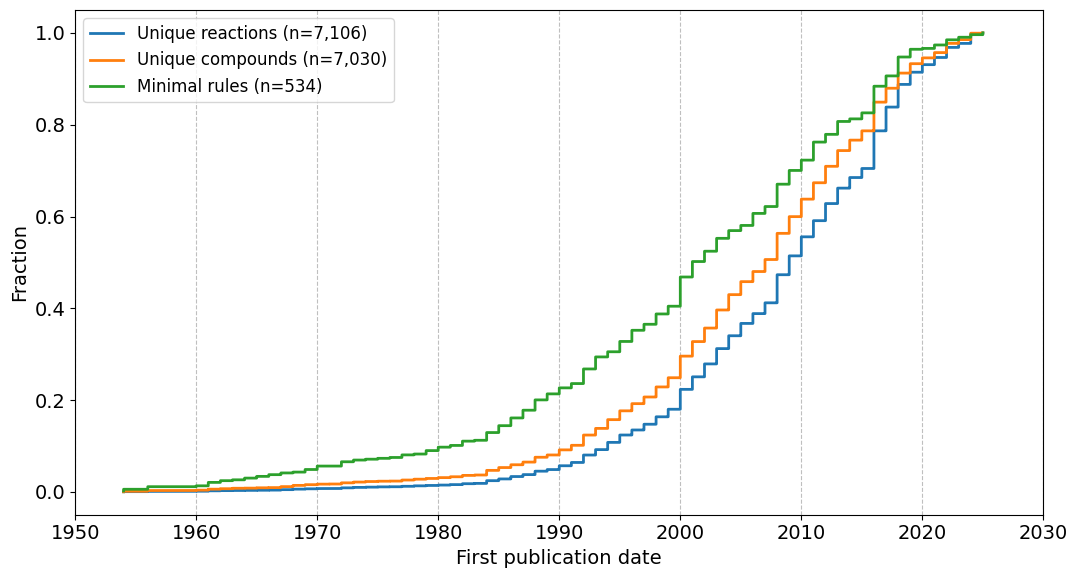

In [14]:
# Build first-publication year per entity
rxn_first = (
    krs_w_date
    .group_by("rxn_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

rule_first = (
    krs_w_date
    .group_by("rule_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

cpd_first = (
    cpd_dates
    .group_by("cpd")
    .agg(pl.col("date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

def ecdf_xy(df, col="year"):
    x = df[col].to_list()
    n = len(x)
    y = [(i + 1) / n for i in range(n)]
    return x, y

x_rxn, y_rxn = ecdf_xy(rxn_first)
x_cpd, y_cpd = ecdf_xy(cpd_first)
x_rule, y_rule = ecdf_xy(rule_first)

all_years = x_rxn + x_cpd + x_rule
x_start = (min(all_years) // 10) * 10
x_end = ((max(all_years) + 9) // 10) * 10

plt.figure(figsize=(11, 6))
plt.step(x_rxn, y_rxn, where="post", label=f"Unique reactions (n={len(x_rxn):,})", linewidth=2)
plt.step(x_cpd, y_cpd, where="post", label=f"Unique compounds (n={len(x_cpd):,})", linewidth=2)
plt.step(x_rule, y_rule, where="post", label=f"Minimal rules (n={len(x_rule):,})", linewidth=2)

plt.xlabel("First publication date")
plt.ylabel("Fraction")
plt.xticks(range(x_start, x_end + 1, 10))
plt.grid(axis="x", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()

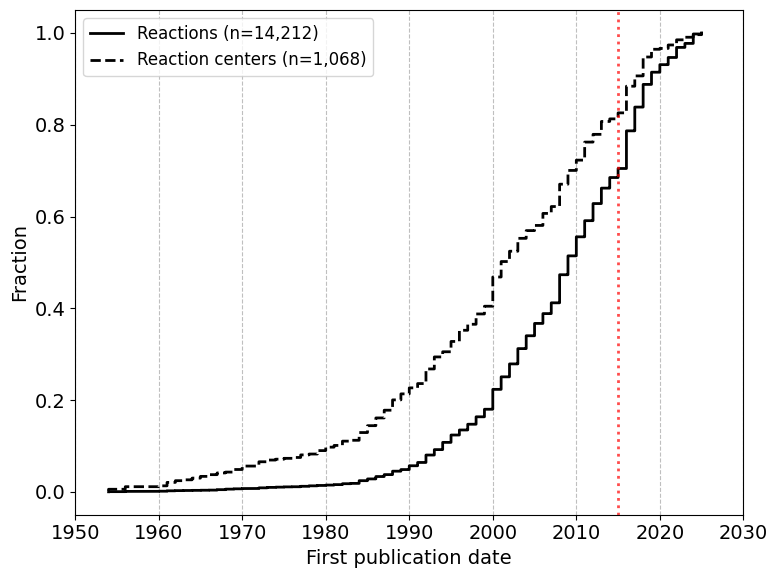

In [15]:
# Build first-publication year per entity
rxn_first = (
    krs_w_date
    .group_by("rxn_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

rule_first = (
    krs_w_date
    .group_by("rule_id")
    .agg(pl.col("first_publication_date").min().alias("year"))
    .drop_nulls("year")
    .sort("year")
)

def ecdf_xy(df, col="year"):
    x = df[col].to_list()
    n = len(x)
    y = [(i + 1) / n for i in range(n)]
    return x, y

x_rxn, y_rxn = ecdf_xy(rxn_first)
x_cpd, y_cpd = ecdf_xy(cpd_first)
x_rule, y_rule = ecdf_xy(rule_first)

all_years = x_rxn + x_cpd + x_rule
x_start = (min(all_years) // 10) * 10
x_end = ((max(all_years) + 9) // 10) * 10

plt.figure(figsize=(8, 6))
plt.step(x_rxn, y_rxn, where="post", label=f"Reactions (n={len(x_rxn)*2:,})", linewidth=2, color="black")
plt.step(x_rule, y_rule, where="post", label=f"Reaction centers (n={len(x_rule)*2:,})", linewidth=2, color="black", linestyle="--")
plt.axvline(x=2015, color="red", linewidth=2, linestyle=":", alpha=0.7)
plt.xlabel("First publication date")
plt.ylabel("Fraction")
plt.xticks(range(x_start, x_end + 1, 10))
plt.grid(axis="x", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()
plt.savefig(Path(cfg.figures) / f"first_publication_dates_w_{cutoff_date}_marked.svg")
plt.show()

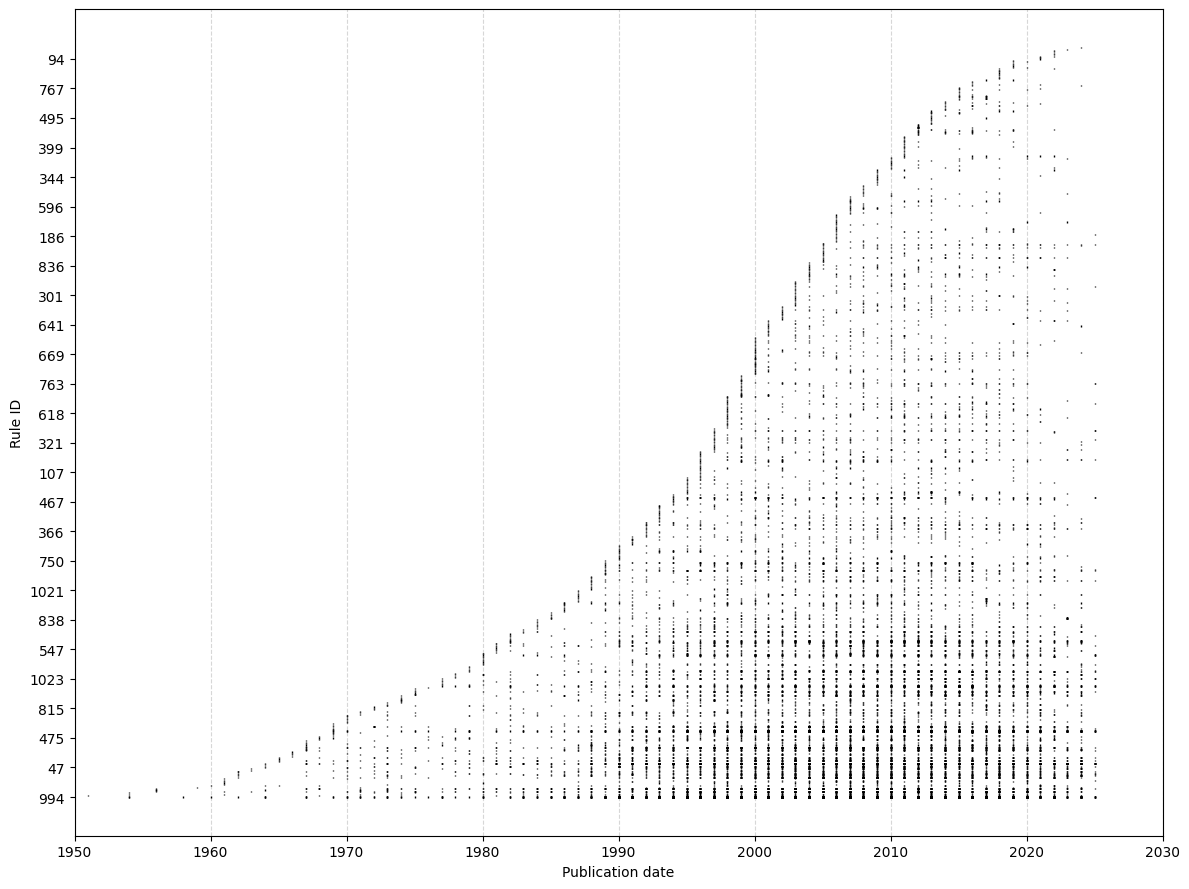

In [16]:
rule_pub = (
    krs_w_date.select(["rule_id", "publication_dates"])
    .explode("publication_dates")
    .rename({"publication_dates": "year"})
    .drop_nulls("year")
)

rule_events = (
    rule_pub
    .group_by("rule_id")
    .agg(
        pl.col("year").sort().alias("years"),
        pl.col("year").min().alias("earliest_year"),
    )
    .sort(["earliest_year", "rule_id"])
)

event_data = rule_events["years"].to_list()
rule_ids_sorted = rule_events["rule_id"].to_list()
line_offsets = list(range(len(rule_ids_sorted)))

plt.figure(figsize=(12, 9))
plt.eventplot(
    event_data,
    orientation="horizontal",
    lineoffsets=line_offsets,
    linelengths=0.8,
    linewidths=1.0,
    colors="black",
)

step = max(1, len(rule_ids_sorted) // 25)
tick_pos = list(range(0, len(rule_ids_sorted), step))
plt.yticks(tick_pos, [rule_ids_sorted[i] for i in tick_pos])

plt.xlabel("Publication date")
plt.ylabel("Rule ID")
plt.xlim(x_start, x_end)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

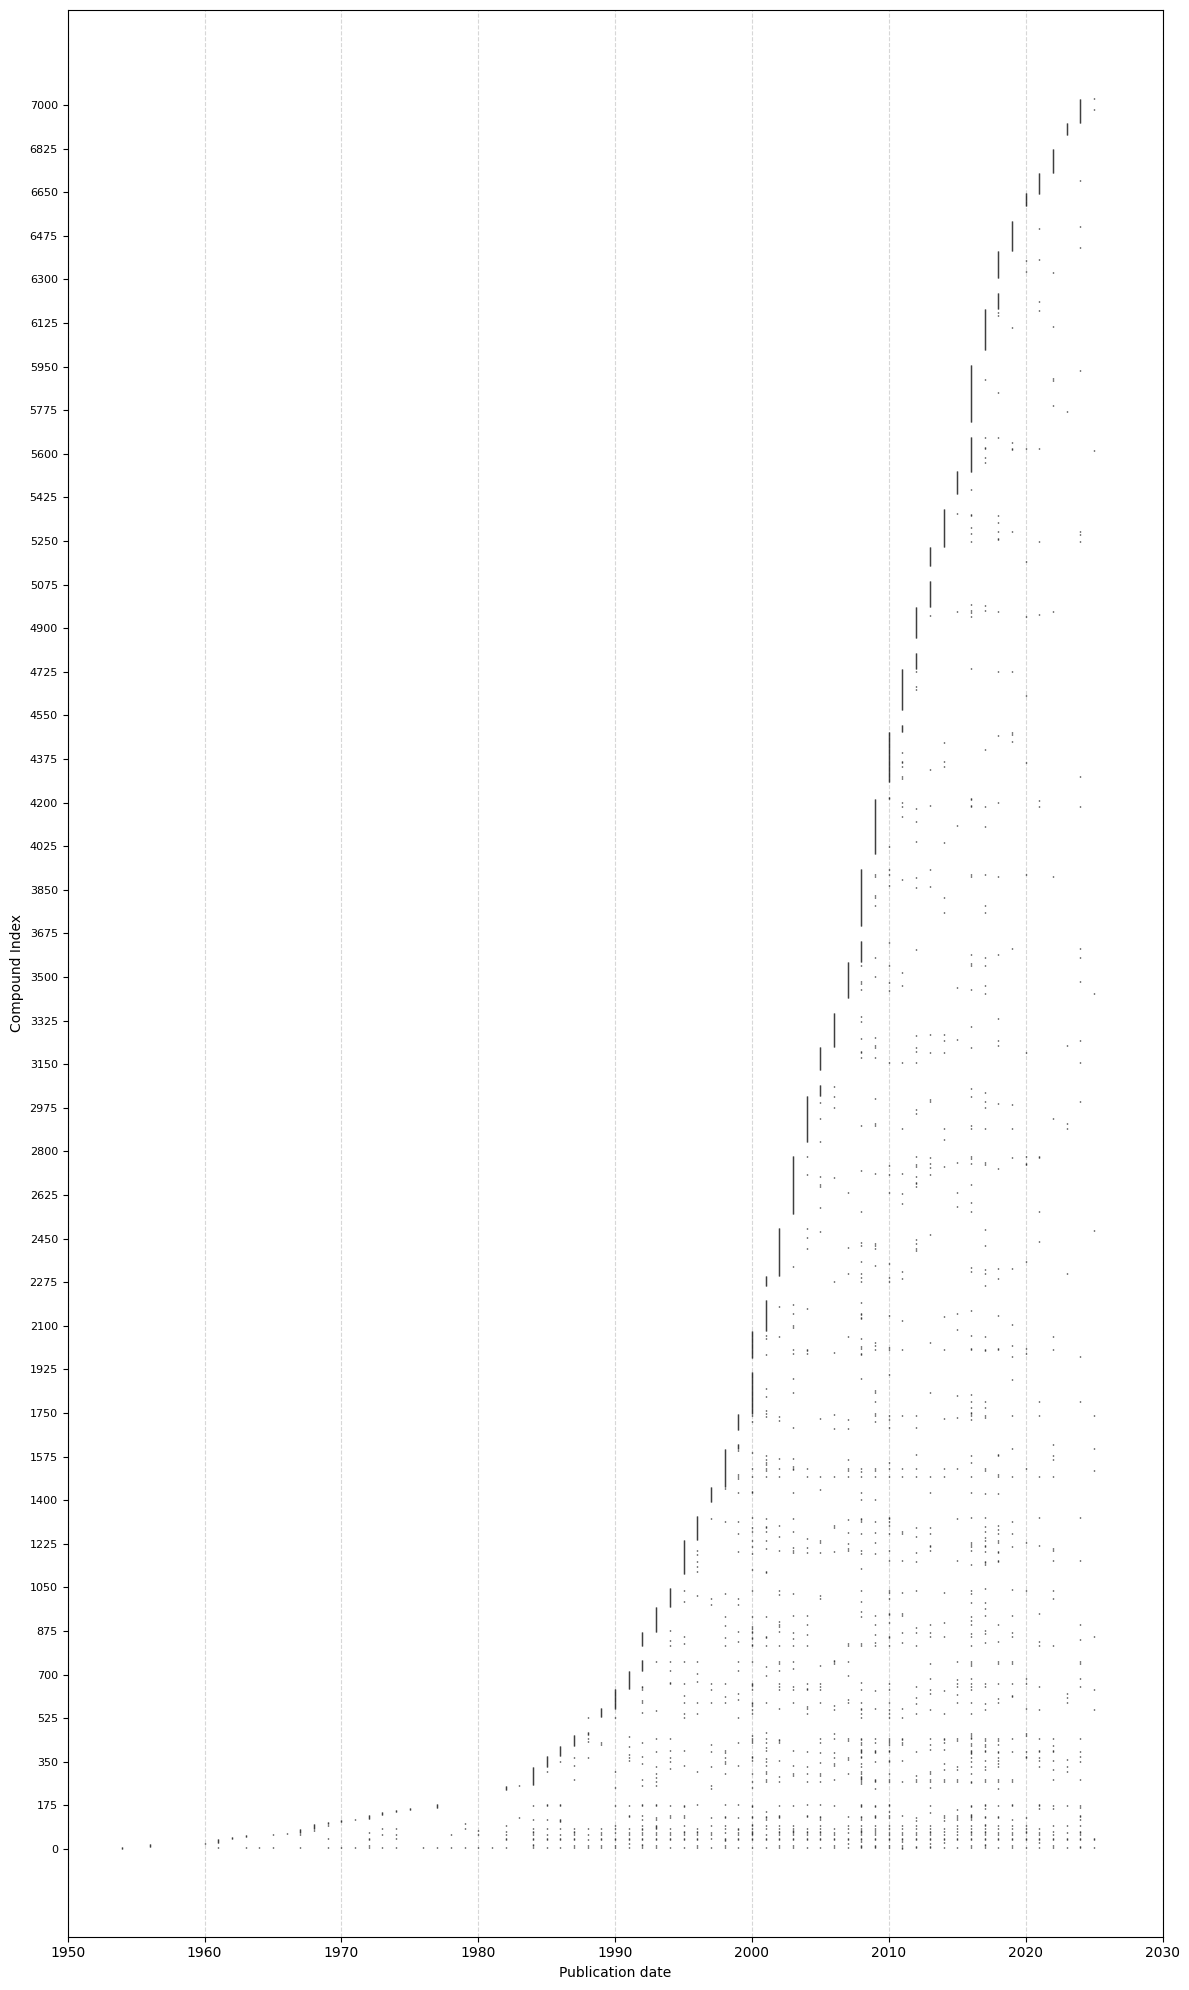

In [17]:
cpd_events = (
    cpd_dates
    .group_by("cpd")
    .agg(
        pl.col("date").sort().alias("years"),
        pl.col("date").min().alias("earliest_date"),
    )
    .sort(["earliest_date", "cpd"])
)

event_data_cpd = cpd_events["years"].to_list()
cpds_sorted = cpd_events["cpd"].to_list()
line_offsets_cpd = list(range(len(cpds_sorted)))

plt.figure(figsize=(12, 20))
plt.eventplot(
    event_data_cpd,
    orientation="horizontal",
    lineoffsets=line_offsets_cpd,
    linelengths=0.8,
    linewidths=1.0,
    colors="black",
)

step_cpd = max(1, len(cpds_sorted) // 40)
tick_pos_cpd = list(range(0, len(cpds_sorted), step_cpd))
plt.yticks(tick_pos_cpd, tick_pos_cpd, fontsize=8)

plt.xlabel("Publication date")
plt.ylabel("Compound Index")
plt.xlim(x_start, x_end)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


Prepare compounds for time split expansions

In [19]:
up_cof = pl.read_csv(Path(cfg.coreactants) / "unpaired.tsv", separator="\t")
p_cof = pl.read_csv(Path(cfg.coreactants) / "paired.tsv", separator="\t")

def std_smi(smiles):
    try:
        return standardize_smiles(smiles)
    except Exception as e:
        print(f"Error standardizing SMILES '{smiles}': {e}")
        return smiles

up_cof = up_cof.with_columns(
    pl.col("smiles").map_elements(std_smi, return_dtype=pl.String).alias("smiles")
)
p_cof = p_cof.with_columns(
    pl.col("smiles_1").map_elements(std_smi, return_dtype=pl.String).alias("smiles_1"),
    pl.col("smiles_2").map_elements(std_smi, return_dtype=pl.String).alias("smiles_2")
)

up_lut = dict(zip(up_cof['smiles'], up_cof['class']))
lhs_p_lut = dict(zip(p_cof['smiles_1'], p_cof['class_1']))
rhs_p_lut = dict(zip(p_cof['smiles_2'], p_cof['class_1'])) # This is not a mistake, just a quick unique id of sorts

[11:01:14] WARNING: not removing hydrogen atom without neighbors


Error standardizing SMILES 'Cc1cc2nc3c(=O)nc(=O)[nH]c-3n(CC(O)C(O)C(O)COP(=O)(O)OP(=O)(O)OCC3OC(n4cnc5c(N)ncnc54)C(O)C3O)c2cc1C': Python argument types in
    rdkit.Chem.rdmolops.RemoveStereochemistry(NoneType)
did not match C++ signature:
    RemoveStereochemistry(RDKit::ROMol {lvalue} mol)
Error standardizing SMILES '*n1c2[nH]c(=O)nc(=O)c-2nc2cc(C)c(C)cc21': Python argument types in
    rdkit.Chem.rdmolops.RemoveStereochemistry(NoneType)
did not match C++ signature:
    RemoveStereochemistry(RDKit::ROMol {lvalue} mol)
Error standardizing SMILES 'Cc1cc2nc3c(=O)nc(=O)[nH]c-3n(CC(O)C(O)C(O)COP(=O)(O)O)c2cc1C': Python argument types in
    rdkit.Chem.rdmolops.RemoveStereochemistry(NoneType)
did not match C++ signature:
    RemoveStereochemistry(RDKit::ROMol {lvalue} mol)
Error standardizing SMILES '*Cn1c2[nH]c(=O)nc(=O)c-2nc2cc(C)c(C)cc21': Python argument types in
    rdkit.Chem.rdmolops.RemoveStereochemistry(NoneType)
did not match C++ signature:
    RemoveStereochemistry(RDKit::ROMol 

In [18]:
krs_w_date.head()

rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,publication_dates,first_publication_date
str,str,str,str,str,i64,list[i32],i32
"""4fc554b86bb64504ce3bb78f4c02ac…","""*C#N.O>>*C(N)=O""","""[*:4][C:2]#[N:1].[OH2:3]>>[*:4…","""[#6:1]#[#7:2].[#8:3]>>[#7:2]-[…","""1,2;0>>1,2,3""",549,"[1989, 1991, … 2025]",2017
"""74aa76da460568ccddd08f17f78cd8…","""*C(*)SSC(*)*.OO>>*C(*)S.*C(*)S…","""[*:3][CH:2]([*:4])[S:1][S:5][C…","""[#16:1]-[#16:2].[#8:3]-[#8:4]>…","""3,4;0,1>>3;3;0,1""",225,"[2000, 2001, … 2019]",2016
"""d31a1334f694b47d6a71cf52dd664a…","""NC(=O)C1=CN(C2OC(COP(=O)(O)OP(…","""[NH2:16][C:15](=[O:17])[C:9]1=…","""[#6:1]1=[#6:2]-[#7:3]-[#6:4]=[…","""3,4,5,45,46,47;1,2>>1,2;3,4,5,…",559,[2011],2011
"""374565644f8e35592c0f7a84b150db…","""*C(NC(=O)CCC(N)C(=O)O)C(=O)O.*…","""[*:18][CH:17]([NH:16][C:1](=[O…","""[#6:1]-[#7:2].[#7:3]>>[#6:1]-[…","""3,2;5>>5,6;2""",316,"[1984, 1991, … 1982]",1984
"""1df0c98f185e6581109d26af4be03e…","""CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C…","""[CH3:51][C:49](=[O:52])[S:1][C…","""[#6:1]-[#16:2].[#7:3]>>[#16:2]…","""1,3;5>>47;5,6""",347,"[2020, 2015]",2020


In [81]:
def remove_cofactors(smarts: str, up_lut: dict[str, str], lhs_p_lut: dict[str, str], rhs_p_lut: dict[str, str]) -> set[str]:
    lhs, rhs = [set(part.split(".")) for part in smarts.split(">>")]
    remaining = lhs.union(rhs)
    for l, r in product(lhs, rhs):
        l_role = lhs_p_lut.get(l)
        r_role = rhs_p_lut.get(r)
        if l_role is not None and r_role is not None and l_role == r_role:
            remaining.discard(l)
            remaining.discard(r)

        l_role = rhs_p_lut.get(l)
        r_role = lhs_p_lut.get(r)
        if l_role is not None and r_role is not None and l_role == r_role:
            remaining.discard(l)
            remaining.discard(r)

        l_role = up_lut.get(l)
        r_role = up_lut.get(r)
        if l_role is not None:
            remaining.discard(l)
        if r_role is not None:
            remaining.discard(r)

    return remaining
    

cpds = set()
for smarts in tqdm(krs_w_date['smarts'], total=len(krs_w_date), desc="Removing cofactors and counting unique compounds"):
    remaining_cpds = remove_cofactors(smarts, up_lut, lhs_p_lut, rhs_p_lut)
    cpds.update(remaining_cpds)

stars = [elt for elt in cpds if "*" in elt]
for star in stars:
    cpds.discard(star)

print(f"Remaining cpds: {len(cpds)}")

Removing cofactors and counting unique compounds:   0%|          | 0/7106 [00:00<?, ?it/s]

Removing cofactors and counting unique compounds: 100%|██████████| 7106/7106 [00:00<00:00, 123030.89it/s]

Remaining cpds: 5810


In [76]:
len(cpds)

6988

In [82]:
# Check that no unpaired cofactors remaining

for smi in up_lut.keys():
    if smi in cpds:
        print(f"Found cofactor {smi} in unique compounds set!")

In [88]:
# Spot check reactions with paired cofactors sanse their better half
def spot_check_lonely_pairs(smarts: str, lhs_p_lut: dict[str, str], rhs_p_lut: dict[str, str], smi2name: dict[str, str]) -> set[str]:
    lhs, rhs = [set(part.split(".")) for part in smarts.split(">>")]
    remaining = lhs.union(rhs)
    for l, r in product(lhs, rhs):
        l_role = lhs_p_lut.get(l)
        r_role = rhs_p_lut.get(r)
        if l_role is not None and r_role is not None and l_role == r_role:
            remaining.discard(l)
            remaining.discard(r)

        l_role = rhs_p_lut.get(l)
        r_role = lhs_p_lut.get(r)
        if l_role is not None and r_role is not None and l_role == r_role:
            remaining.discard(l)
            remaining.discard(r)

        l_role = up_lut.get(l)
        r_role = up_lut.get(r)
        if l_role is not None:
            remaining.discard(l)
        if r_role is not None:
            remaining.discard(r)

    stars = [elt for elt in remaining if "*" in elt]
    for star in stars:
        remaining.discard(star)

    hybrids = set()
    if any([elt in lhs_p_lut for elt in remaining]) or any([elt in rhs_p_lut for elt in remaining]):
        for elt in remaining:
            if elt in lhs_p_lut:
                print(f"Lonely paired cofactor on LHS: {elt}, Name: {smi2name[elt]}  (class {lhs_p_lut[elt]})")
                hybrids.add((elt, smi2name[elt]))
            if elt in rhs_p_lut:
                print(f"Lonely paired cofactor on RHS: {elt}, Name: {smi2name[elt]} (class {rhs_p_lut[elt]})")
                hybrids.add((elt, smi2name[elt]))
        print(smarts)

    return hybrids

smi2name = {**dict(zip(p_cof['smiles_1'], p_cof['name_1'])), **dict(zip(p_cof['smiles_2'], p_cof['name_2']))}

hybrids = set()
for smarts in tqdm(krs_w_date['smarts'], total=len(krs_w_date), desc="Spot checking for lonely paired cofactors"):
    hybrids.update(spot_check_lonely_pairs(smarts, lhs_p_lut, rhs_p_lut, smi2name))

Spot checking for lonely paired cofactors:   0%|          | 0/7106 [00:00<?, ?it/s]

Spot checking for lonely paired cofactors: 100%|██████████| 7106/7106 [00:00<00:00, 44721.96it/s]

Lonely paired cofactor on LHS: O=C(O)CCC(=O)C(=O)O, Name: 2-oxoglutarate  (class CARBONYL_CoF)
*C(=O)C1C(O)CCN1*.O=C(O)CCC(=O)C(=O)O.O=O>>*C(=O)C1C(O)C(O)CN1*.O=C(O)CCC(=O)O.O=C=O
Lonely paired cofactor on LHS: O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1, Name: UDP  (class PHOSPHATE_DONOR_CoF)
Lonely paired cofactor on RHS: O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1, Name: UDP (class GLUCOSYL_DONOR_CoF)
CC(=O)NC1C(OP(=O)(O)OP(=O)(O)OCC2OC(n3ccc(=O)[nH]c3=O)C(O)C2O)OC(CO)C(O)C1O.*C(=O)C1CC(O)CN1*>>*C(=O)C1CC(OC2OC(CO)C(O)C(O)C2NC(C)=O)CN1*.O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1
Lonely paired cofactor on LHS: O=C(O)CCC(=O)C(=O)O, Name: 2-oxoglutarate  (class CARBONYL_CoF)
*C(=O)C1CC(O)CN1*.O=C(O)CCC(=O)O.O=C=O>>*C(=O)C1CCCN1*.O=C(O)CCC(=O)C(=O)O.O=O
Lonely paired cofactor on LHS: O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1, Name: UDP  (class PHOSPHATE_DONOR_CoF)
Lonely paired cofactor on RHS: O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1, 

In [89]:
for elt in hybrids:
    print(f"Paired cofactor without its partner: {elt[0]}, Name: {elt[1]}")

Paired cofactor without its partner: Nc1ccn(C2OC(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)n1, Name: CTP
Paired cofactor without its partner: CP(=O)(O)OC1OC(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)C(O)C1O, Name: alpha-D-ribose 1-methylphosphonate 5-triphosphate
Paired cofactor without its partner: NCC(=O)NC1OC(COP(=O)(O)O)C(O)C1O, Name: N(1)-(5-phospho-beta-D-ribosyl)glycinamide
Paired cofactor without its partner: O=c1ccn(C2OC(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)C(O)C2O)c(=O)[nH]1, Name: UTP
Paired cofactor without its partner: O=c1[nH]cnc2c1ncn2C1CC(O)C(COP(=O)(O)O)O1, Name: dIMP
Paired cofactor without its partner: Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(O)C1O, Name: AMP
Paired cofactor without its partner: Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(OP(=O)(O)O)C1O, Name: adenosine 3',5'-bisphosphate
Paired cofactor without its partner: NC(=O)c1ccc[n+](C2OC(CO)C(O)C2O)c1, Name: beta-nicotinamide D-riboside
Paired cofactor without its partner: Nc1ncnc2c1ncn2C1OC(COP(=O)(O)OP(=O)(O)OCC2OC(OP(=O)(O)O)C(O)C2O)C(O)C1O, 

In [90]:
whitelist = set(
    [
        'Cc1cc(O)c2ccccc2c1O',
        'CCC(C)C(N)C(=O)O',
        'CCC(=O)C(=O)O',
        'CC(N)C(=O)O',
        'O=CC(=O)O',
        'NC(CC(=O)O)C(=O)O',
        'NC(CCC(=O)O)C(=O)O',
        'CCCCC(=O)C(=O)O',
        'CSCCC(N)C(=O)O',
        'NCC(=O)O',
        'OCC1OC(O)C(O)C1O'
        'C[S+](C)CCC(N)C(=O)O'
        'CSCCC(=O)C(=O)O'
        'OCC1OC(O)(CO)C(O)C1O',
        'O=C(O)CCC(=O)C(=O)O',
        'CCCC(=O)C(=O)O',
        'Nc1ccccc1C(=O)CC(N)C(=O)O',
        'Nc1ccn(C2OC(COP(=O)(O)OP(=O)(O)OC3OC(CO)C(O)C(O)C3O)C(O)C2O)c(=O)n1',
        'O=[N+]([O-])c1ccc(O)cc1',
        'CC(C)CC(=O)C(=O)O',
        'O=C(O)C(=O)CO',
        'O=c1[nH]cnc2c1ncn2C1CC(O)C(CO)O1',
        'NC(=O)CC(=O)C(=O)O',
        'CC(C)C(=O)C(=O)O',
        'O=c1ccn(C2OC(CO)C(O)C2O)c(=O)[nH]1',
        'O=c1[nH]c(=O)c2ncn(C3OC(CO)C(O)C3O)c2[nH]1',
        'CC(C)CC(N)C(=O)O',
        'CC(C)C(N)C(=O)O',
        'NC(=O)CC(N)C(=O)O',
        'CCC(C)C(=O)C(=O)O',
        'O=C(O)CC(=O)C(=O)O',
        'CCC(N)C(=O)O',
        'CC(=O)C(=O)O',
        'NC(CO)C(=O)O',
    ]
)

def final_filter(cpds: set[str], whitelist: set[str], lhs_p_lut: dict[str, str], rhs_p_lut: dict[str, str]) -> set[str]:
    filtered = set()
    for cpd in cpds:
        if cpd in whitelist:
            filtered.add(cpd)
            continue
        
        if cpd in lhs_p_lut or cpd in rhs_p_lut:
            continue

        filtered.add(cpd)

    return filtered

cpds = final_filter(cpds, whitelist, lhs_p_lut, rhs_p_lut)
print(f"Length of final unique compounds set: {len(cpds)}")

Length of final unique compounds set: 5709


In [104]:
cpds_in_post_2015_rxns = set()
cpds_in_post_2020_rxns = set()
for row in krs_w_date.iter_rows(named=True):
    smarts = row['smarts']
    year = row['first_publication_date']
    if year is not None:
        if year >= 2015:
            cpds_in_post_2015_rxns.update(get_unique_cpds(smarts))
        if year >= 2020:
            cpds_in_post_2020_rxns.update(get_unique_cpds(smarts))

after_2015_cpds = cpds.intersection(cpds_in_post_2015_rxns)
after_2020_cpds = cpds.intersection(cpds_in_post_2020_rxns)

In [106]:
kcs = pl.read_parquet(Path(cfg.raw_data) / "known_compounds.parquet")
full_smi2name = dict(zip(kcs['smiles'], kcs['name']))

after_2015_starters = pl.DataFrame(
    [(full_smi2name.get(smi, f"Unknown_{i}"), smi) for i, smi in enumerate(after_2015_cpds)],
    schema=['id', 'smiles'],
    orient="row"
)

after_2020_starters = pl.DataFrame(
    [(full_smi2name.get(smi, f"Unknown_{i}"), smi) for i, smi in enumerate(after_2020_cpds)],
    schema=['id', 'smiles'],
    orient="row"
)

all_time_starters = pl.DataFrame(
    [(full_smi2name.get(smi, f"Unknown_{i}"), smi) for i, smi in enumerate(cpds)],
    schema=['id', 'smiles'],
    orient="row"
)

after_2015_starters.write_csv(Path(cfg.starters) / "after_2015_cpds.csv")
after_2020_starters.write_csv(Path(cfg.starters) / "after_2020_cpds.csv")
all_time_starters.write_csv(Path(cfg.starters) / "all_time_cpds.csv")

after_2015_starters.head()

id,smiles
str,str
"""propanal""","""CCC=O"""
"""sphing-4-enine 1-phosphate""","""CCCCCCCCCCCCCC=CC(O)C(N)COP(=O…"
"""indole-3-carbaldehyde""","""O=Cc1c[nH]c2ccccc12"""
"""enol-oxaloacetate""","""O=C(O)C=C(O)C(=O)O"""
"""2,4,7,9-tetrahydroxy-6-methyl-…","""C=CC(C)(C)c1c(O)c2c3c(c(O)cc(C…"
